# **Prepare and Load the data**

In [73]:
# import libraries

# Data Manipulation libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing Libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Machine Learning Libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [74]:
# import data
df = pd.read_csv('StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [75]:
# show information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

# **Exploratory Data Analysis**

In [76]:
# show decritive statistics about the data
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [77]:
# numerical column
numerical_col = df.select_dtypes(include = ['int64', 'float64']).columns
print(numerical_col)

print('-'*75)

# categorical column
categorcial_col = df.select_dtypes(include = ['object']).columns
print(categorcial_col)

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='object')
---------------------------------------------------------------------------
Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')


In [78]:
# lenght of numerical and categorical columns
print(f'number of numerical columns: {len(numerical_col)}')
print(f'number of categorical columns: {len(categorcial_col)}')

number of numerical columns: 7
number of categorical columns: 13


In [79]:
# check the missing values
print(df.isnull().sum())

print('-'*35)

# check duplicated values
print(df.duplicated().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64
-----------------------------------
0


- there's missing value in 'Teacher_Quality', 'Parental_Education_Level', and 'Distance_from_Home' column

- there's no duplicated value

**Fill the missing value**

In [80]:
# fill the missing value in the column with mode

# fill the missing value in the 'Teacher_Quality' column
df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)

# fill the missing value in the 'Parental_Education_Level' column
df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0], inplace=True)

# fill the missing value in the 'Distance_from_Home' column
df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0], inplace=True)

# check the missing values again after filling
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

**show data distribution of the numerical columns**

In [81]:
# make function to check plot the distribution of the numerical columns
def plot_distribution(column):
    plt.figure(figsize=(7, 5))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# make function to check count plot for categorical columns
def count_plot(column):
    plt.figure(figsize=(7, 5))
    sns.countplot(x=df[column], palette='tab10')
    plt.title(f'Count Plot of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

**Distribution of Numerical Columns**

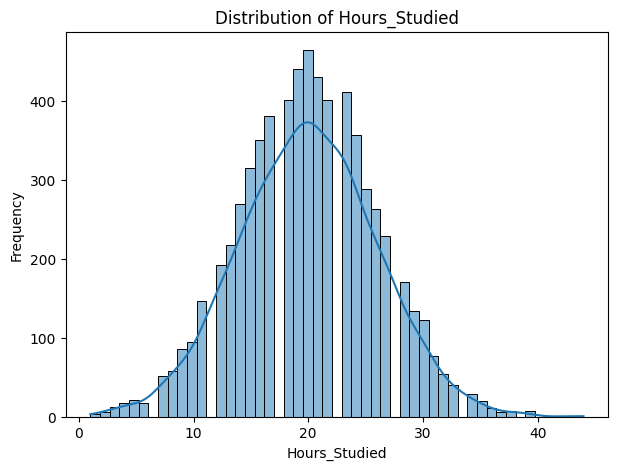

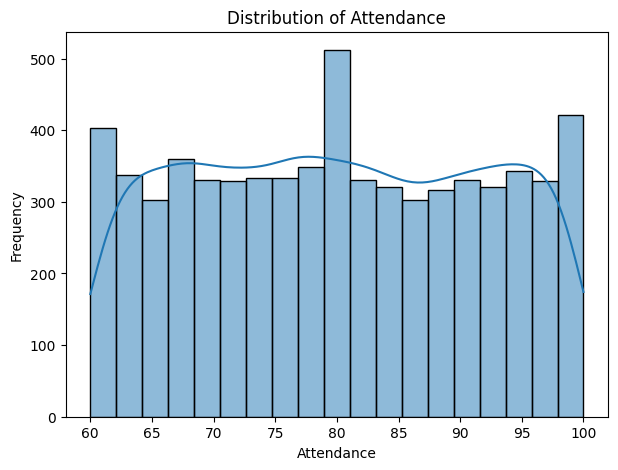

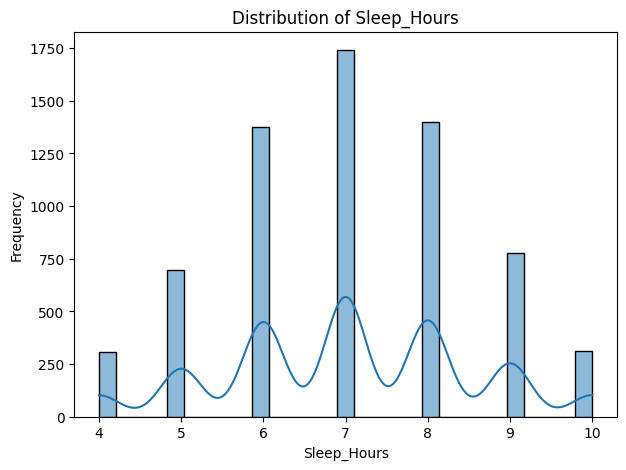

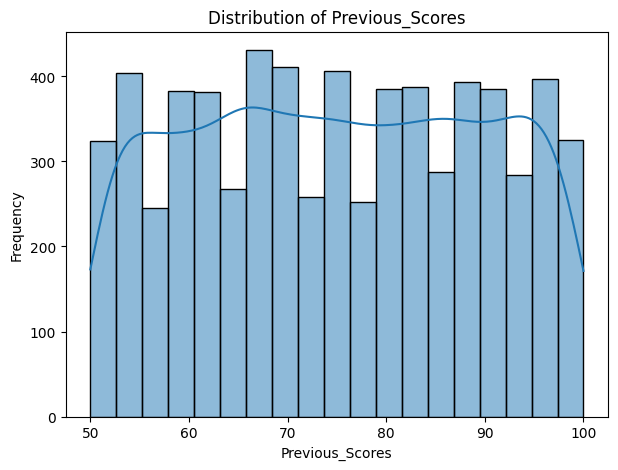

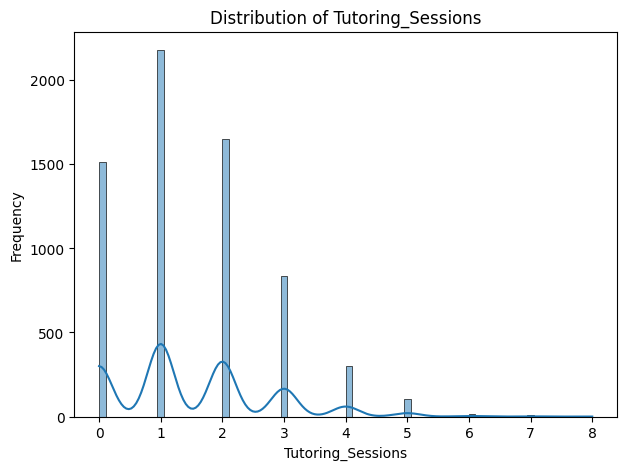

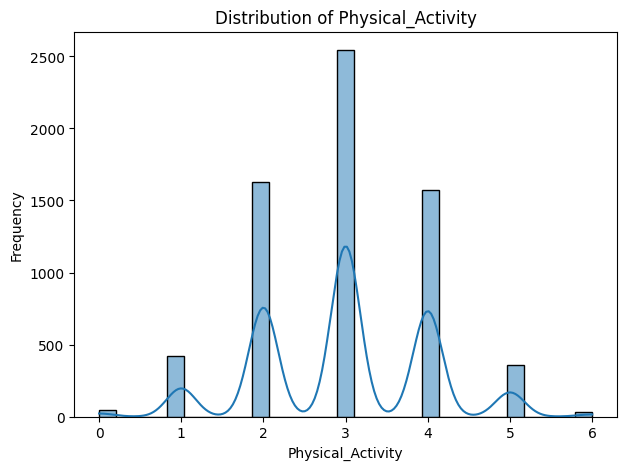

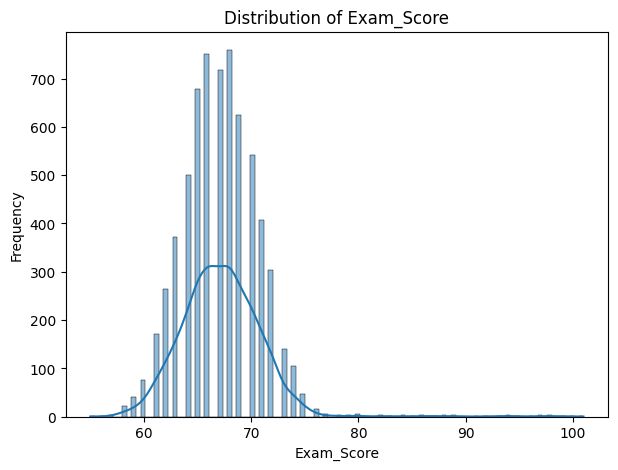

In [82]:
# check the distribution of the numerical columns
for col in numerical_col:
    plot_distribution(col)
    print('')

**Count Plot of Categorical Columns**

C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


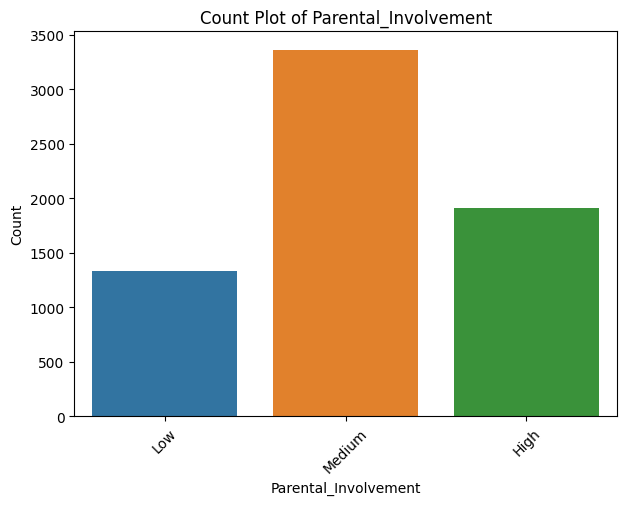

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


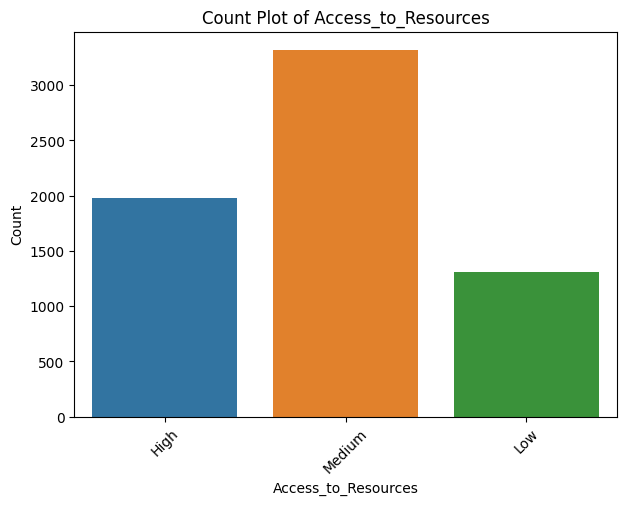

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


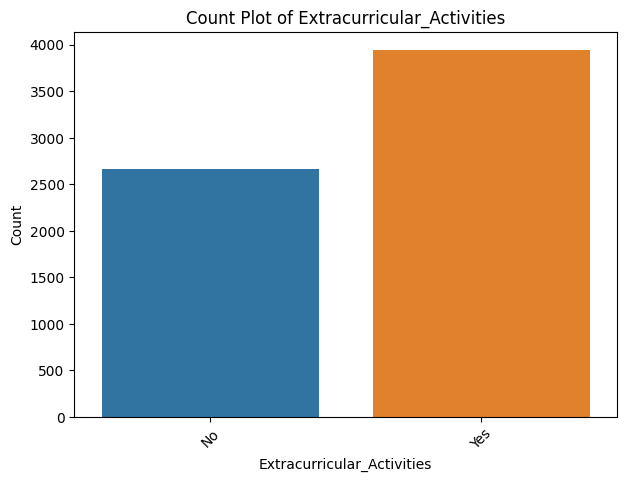

Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


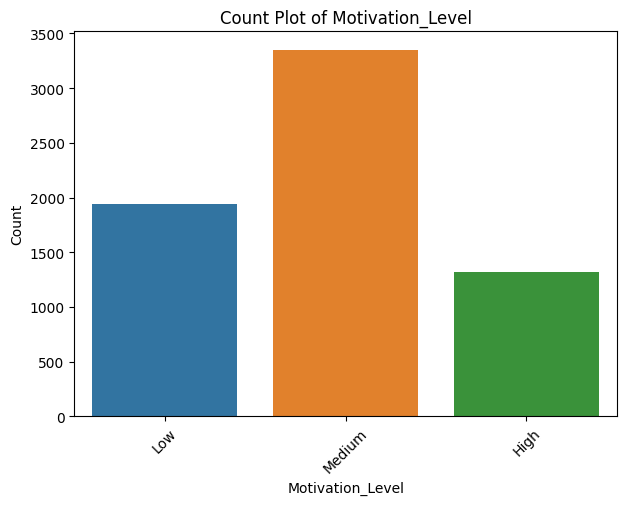

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


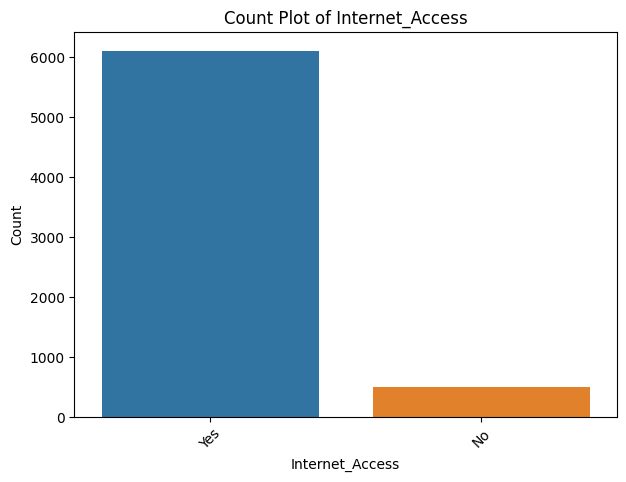

Internet_Access
Yes    6108
No      499
Name: count, dtype: int64


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


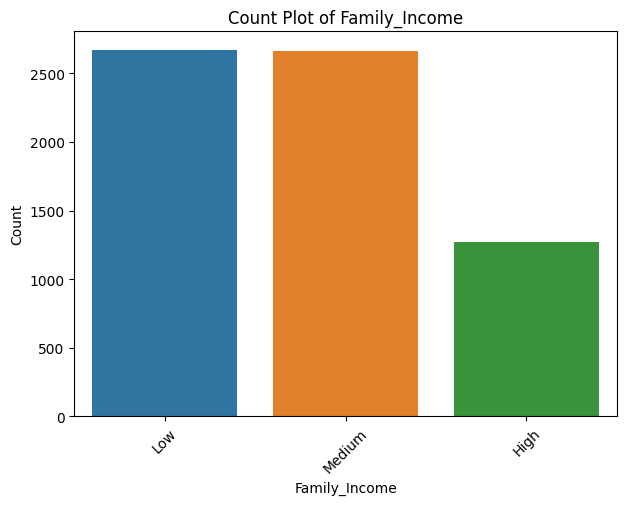

Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


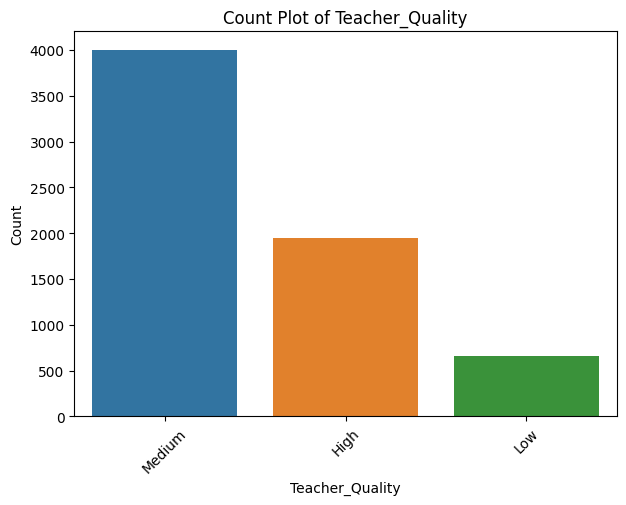

Teacher_Quality
Medium    4003
High      1947
Low        657
Name: count, dtype: int64


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


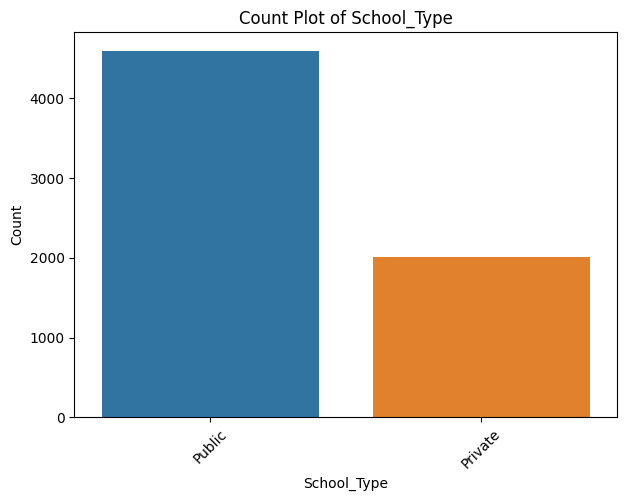

School_Type
Public     4598
Private    2009
Name: count, dtype: int64


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


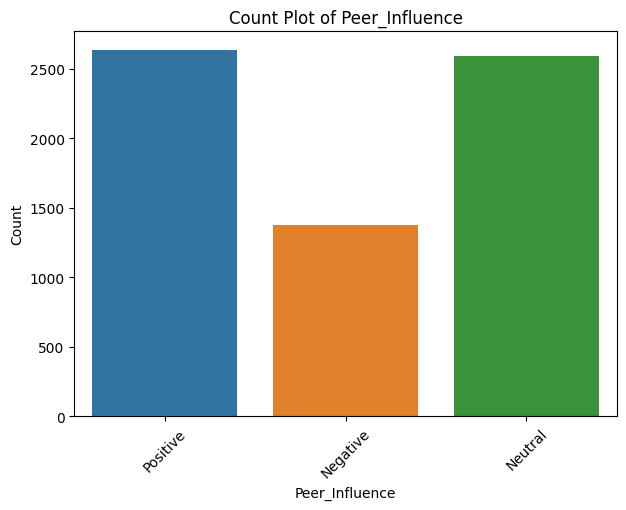

Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


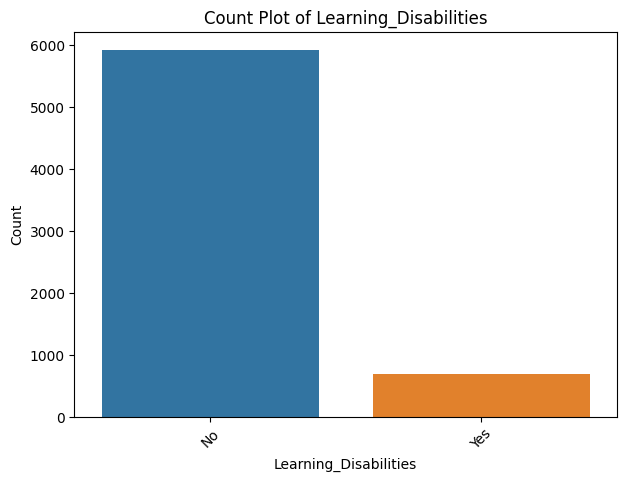

C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64


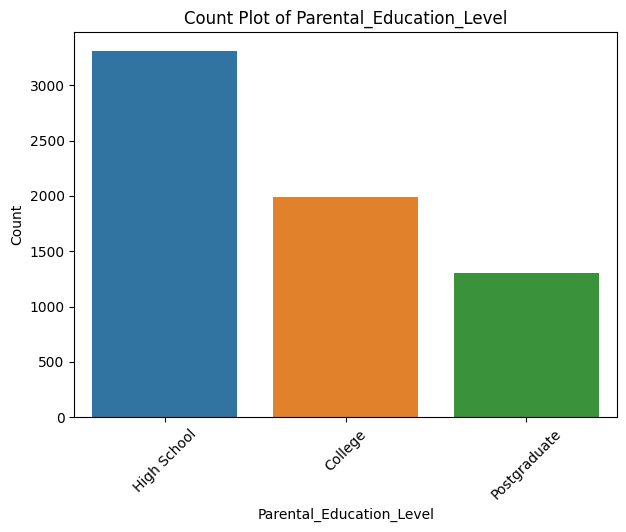

Parental_Education_Level
High School     3313
College         1989
Postgraduate    1305
Name: count, dtype: int64


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


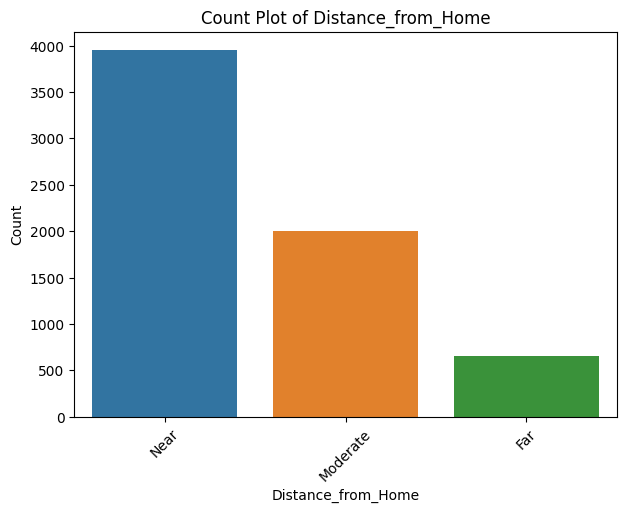

Distance_from_Home
Near        3951
Moderate    1998
Far          658
Name: count, dtype: int64


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\2338474052.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


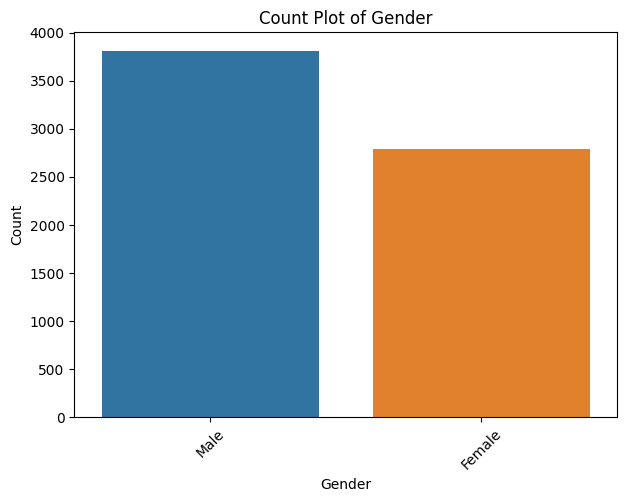

Gender
Male      3814
Female    2793
Name: count, dtype: int64


In [83]:
# check the count plot for categorical columns and add value counts to the plot
for col in categorcial_col:
    count_plot(col)
    print(df[col].value_counts())

**Feature vs target (exam_score)**

Text(0, 0.5, 'Exam Score')

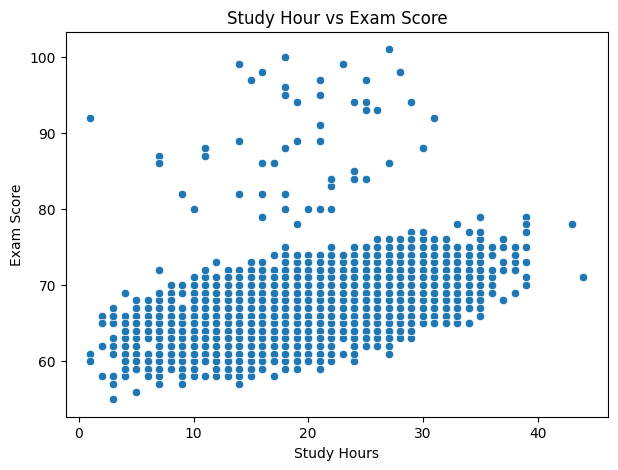

In [84]:
# show hourly study time vs final grade
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df)
plt.title('Study Hour vs Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')

There is a clear positive trend. Students who study more than 25 hours tend to get scores above 70.

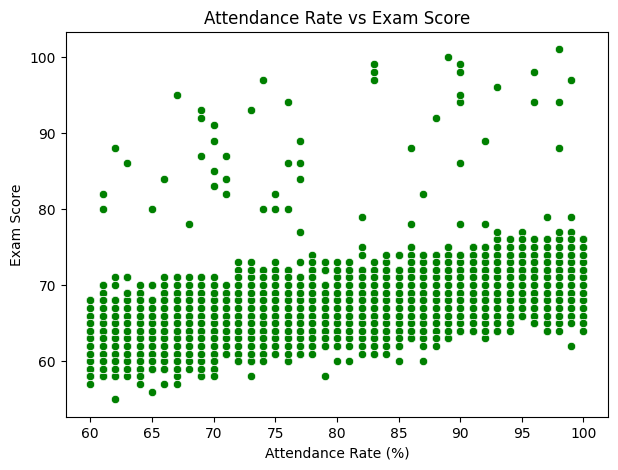

In [85]:
# show attendance vs final grade
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Attendance', y='Exam_Score', data=df, color='GREEN')
plt.title('Attendance Rate vs Exam Score')
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Exam Score')
plt.show()

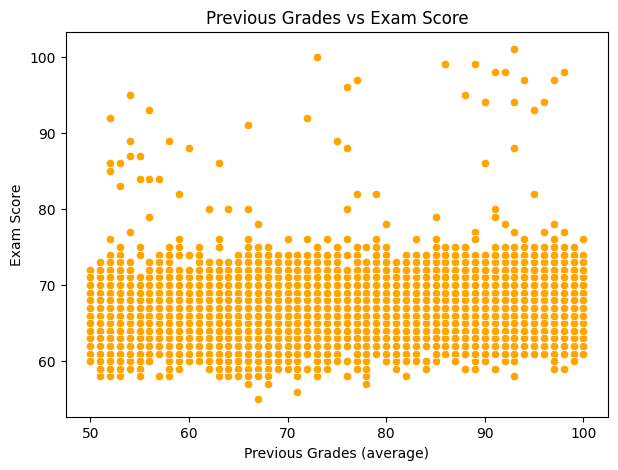

In [86]:
# show previous grades vs final grade
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Previous_Scores', y='Exam_Score', data=df, color='ORANGE')
plt.title('Previous Grades vs Exam Score')
plt.xlabel('Previous Grades (average)')
plt.ylabel('Exam Score')
plt.show()

# **Bivariate Analysis**

Average Exam Score for Male: 67.23
Average Exam Score for Female: 67.24


C:\Users\arifi_fev3zac\AppData\Local\Temp\ipykernel_11940\836101140.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Male', 'Female'], y=[male_avg_score, female_avg_score], palette='Set2')


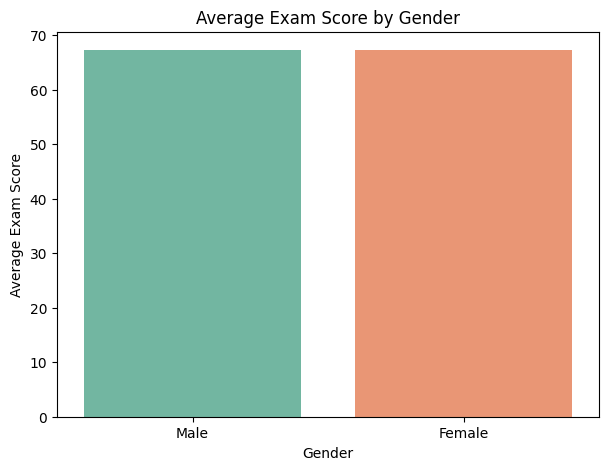

In [87]:
# avergae exam score by gender
male_avg_score = df[df['Gender'] == 'Male']['Exam_Score'].mean()
female_avg_score = df[df['Gender'] == 'Female']['Exam_Score'].mean()

print(f'Average Exam Score for Male: {male_avg_score:.2f}')
print(f'Average Exam Score for Female: {female_avg_score:.2f}')

# create a bar plot to compare the average exam score
plt.figure(figsize=(7, 5))
sns.barplot(x=['Male', 'Female'], y=[male_avg_score, female_avg_score], palette='Set2')
plt.title('Average Exam Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Exam Score')
plt.show()

# **Data Manipulation**

In [88]:
# sort the dataframe by exam score in descending order
df.sort_values(by='Exam_Score', ascending=False).head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
2425,23,83,High,High,Yes,4,89,Low,Yes,1,Medium,Medium,Public,Negative,3,No,High School,Far,Male,99
3579,14,90,High,High,Yes,8,86,Medium,Yes,4,Medium,Medium,Private,Negative,2,No,High School,Near,Female,99
6347,28,96,High,Low,Yes,4,98,High,Yes,1,High,High,Public,Positive,3,No,High School,Near,Male,98


# **Outlier Detection With Box Plot**

In [89]:
# make function to check the box plot for numerical columns
def box_plot(column):
    plt.figure(figsize=(9, 5))
    sns.boxplot(x=df[column], color='red')
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.show()

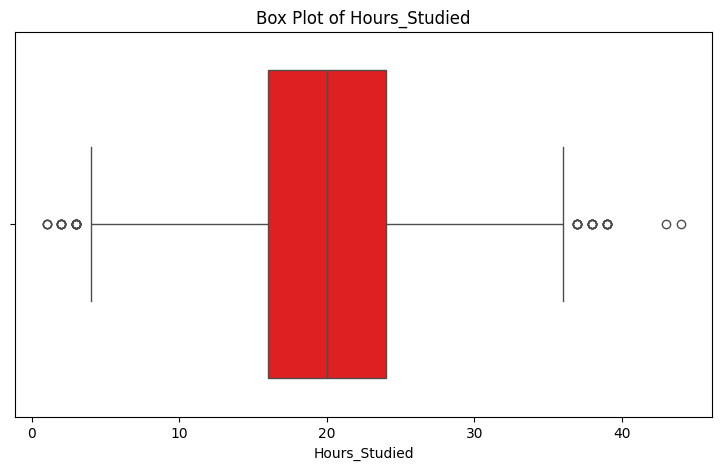

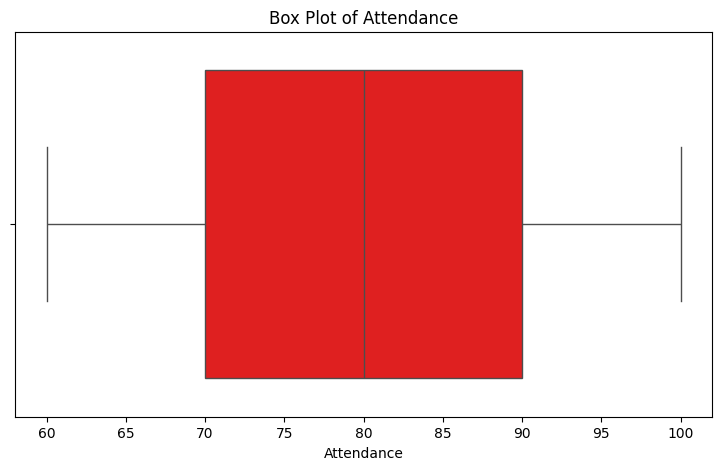

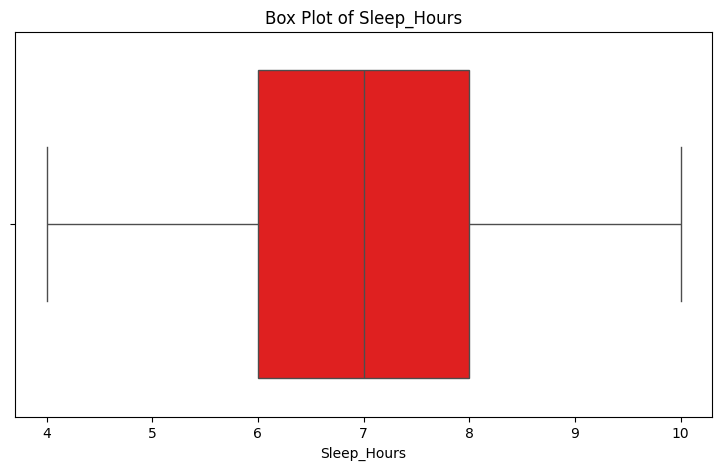

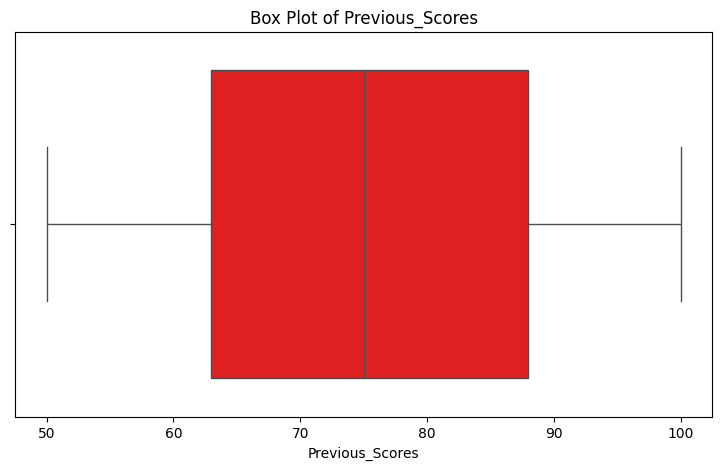

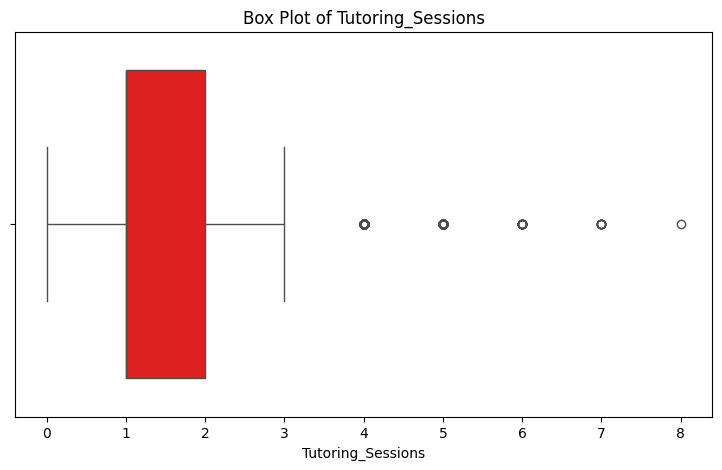

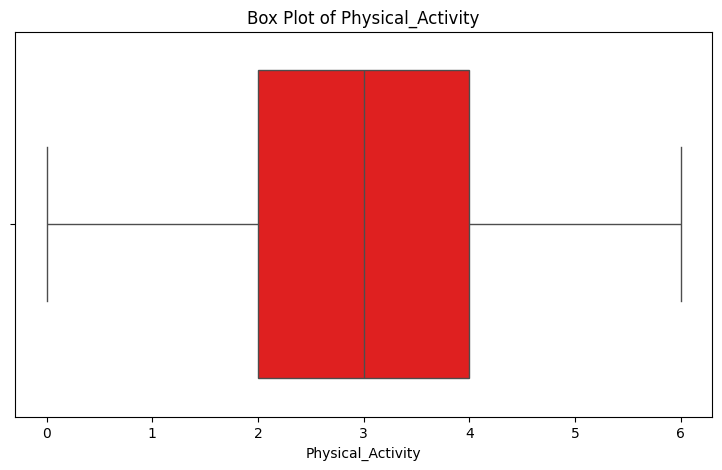

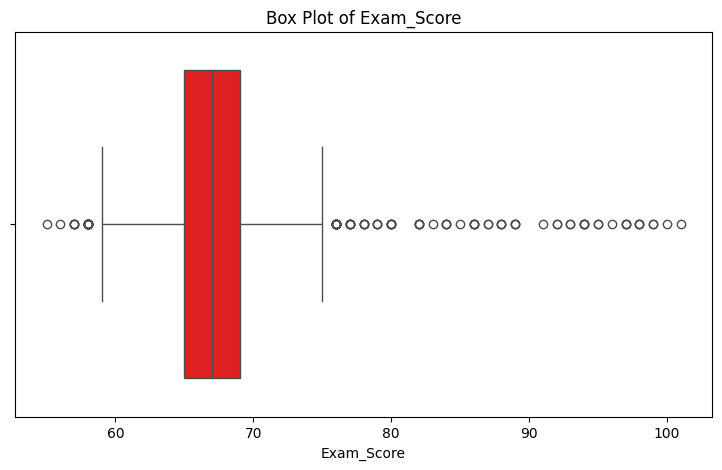

In [90]:
# check the box plot for numerical columns
for col in numerical_col:
    box_plot(col)
    print('')

# **Correlation check**

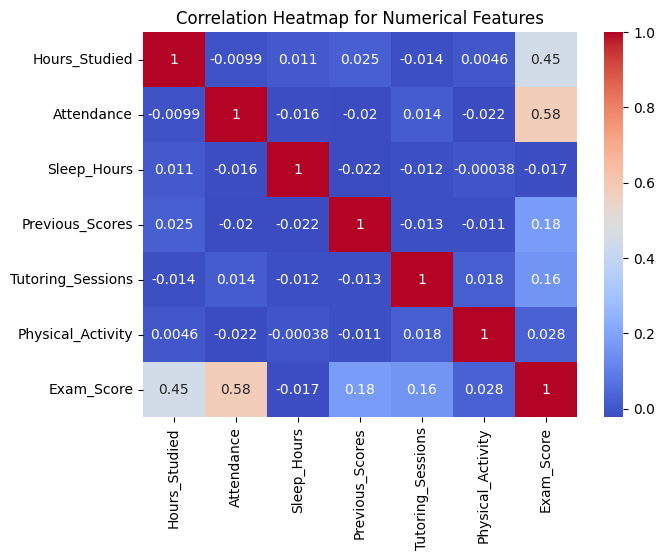

In [91]:
# chech correlation with heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df[numerical_col].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for Numerical Features')
plt.show()

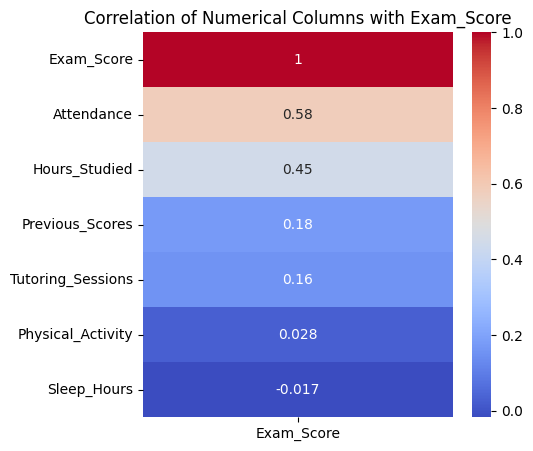

In [92]:
# correlation check numerical columns with target variable 'Exam_Score'
plt.figure(figsize=(5,5))
sns.heatmap(df[numerical_col].corr()['Exam_Score'].sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm')
plt.title('Correlation of Numerical Columns with Exam_Score')
plt.show()

Attendance and Hours_Studied have a strong correlation with Exam_Score. Previous_Scores and Distance_from_Home have a weak correlation with Exam_Score.

# **Encoding Categorical Variables**

**group numeric column, ordinal column and nominal column**

In [93]:
# show columns name of categorical columns
print(categorcial_col)

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [95]:
print('Numerical Columns:')
numerical_col = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Physical_Activity'
]
numerical_col

Numerical Columns:


['Hours_Studied',
 'Attendance',
 'Sleep_Hours',
 'Previous_Scores',
 'Tutoring_Sessions',
 'Physical_Activity']

In [96]:
# ordinal columns
print('Ordinal Columns:')
ordinal_col = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality',
    'Peer_Influence',
    'Parental_Education_Level',
    'Distance_from_Home'
]
ordinal_col

Ordinal Columns:


['Parental_Involvement',
 'Access_to_Resources',
 'Motivation_Level',
 'Family_Income',
 'Teacher_Quality',
 'Peer_Influence',
 'Parental_Education_Level',
 'Distance_from_Home']

In [97]:
# nominal columns
print('Nominal Columns:')
nominal_col = [
    'Gender',
    'Internet_Access',
    'Extracurricular_Activities',
    'Learning_Disabilities',
    'School_Type'
]
nominal_col

Nominal Columns:


['Gender',
 'Internet_Access',
 'Extracurricular_Activities',
 'Learning_Disabilities',
 'School_Type']

In [98]:
# check the value counts for ordinal columns
for col in ordinal_col:
    print(df[col].value_counts())
    print('-'*30)

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64
------------------------------
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64
------------------------------
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64
------------------------------
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64
------------------------------
Teacher_Quality
Medium    4003
High      1947
Low        657
Name: count, dtype: int64
------------------------------
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64
------------------------------
Parental_Education_Level
High School     3313
College         1989
Postgraduate    1305
Name: count, dtype: int64
------------------------------
Distance_from_Home
Near        3951
Moderate    1998
Far          658
Name: count, dtype: int64
------------------------------


In [99]:
# check the value counts for nominal columns
for col in nominal_col:
    print(df[col].value_counts())
    print('-'*30)

Gender
Male      3814
Female    2793
Name: count, dtype: int64
------------------------------
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64
------------------------------
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64
------------------------------
Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64
------------------------------
School_Type
Public     4598
Private    2009
Name: count, dtype: int64
------------------------------


**Encoding the categorical column**

In [100]:
# make dictionary to map ordinal columns
from sklearn.preprocessing import OrdinalEncoder

# create a dictionary to map the ordinal columns with their respective categories
ordinal_col = {
    'Parental_Involvement': ['Low', 'Medium', 'High'],
    'Access_to_Resources': ['Low', 'Medium', 'High'],
    'Motivation_Level': ['Low', 'Medium', 'High'],
    'Family_Income': ['Low', 'Medium', 'High'],
    'Teacher_Quality': ['Low', 'Medium', 'High'],
    'Peer_Influence': ['Negative', 'Neutral', 'Positive'],
    'Parental_Education_Level': ['High School', 'College', 'Postgraduate'],
    'Distance_from_Home': ['Near', 'Moderate', 'Far']
}

# encode the ordinal columns using OrdinalEncoder
encoder = OrdinalEncoder(categories=list(ordinal_col.values()))

# transform the ordinal columns and update the dataframe
df[list(ordinal_col.keys())] = encoder.fit_transform(df[list(ordinal_col.keys())])

In [101]:
# encode the nominal columns
df=pd.get_dummies(df, columns=nominal_col, drop_first=True)

**Check the data after encoding**

In [102]:
# show 5 first rows after encoding
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Gender_Male,Internet_Access_Yes,Extracurricular_Activities_Yes,Learning_Disabilities_Yes,School_Type_Public
0,23,84,0.0,2.0,7,73,0.0,0,0.0,1.0,2.0,3,0.0,0.0,67,True,True,False,False,True
1,19,64,0.0,1.0,8,59,0.0,2,1.0,1.0,0.0,4,1.0,1.0,61,False,True,False,False,True
2,24,98,1.0,1.0,7,91,1.0,2,1.0,1.0,1.0,4,2.0,0.0,74,True,True,True,False,True
3,29,89,0.0,1.0,8,98,1.0,1,1.0,1.0,0.0,4,0.0,1.0,71,True,True,True,False,True
4,19,92,1.0,1.0,6,65,1.0,3,1.0,2.0,1.0,4,1.0,0.0,70,False,True,True,False,True


In [103]:
# describe the data after encoding
df.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,1.086423,1.100197,7.02906,75.070531,0.906463,1.493719,0.787649,1.195247,1.190858,2.967610,0.696080,0.501589,67.235659
std,5.990594,11.547475,0.695521,0.698347,1.46812,14.399784,0.695798,1.230570,0.742617,0.596707,0.755876,1.031231,0.778897,0.670260,3.890456
min,1.000000,60.000000,0.000000,0.000000,4.00000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,1.000000,1.000000,6.00000,63.000000,0.000000,1.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,65.000000
50%,20.000000,80.000000,1.000000,1.000000,7.00000,75.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000,0.000000,67.000000
75%,24.000000,90.000000,2.000000,2.000000,8.00000,88.000000,1.000000,2.000000,1.000000,2.000000,2.000000,4.000000,1.000000,1.000000,69.000000
max,44.000000,100.000000,2.000000,2.000000,10.00000,100.000000,2.000000,8.000000,2.000000,2.000000,2.000000,6.000000,2.000000,2.000000,101.000000


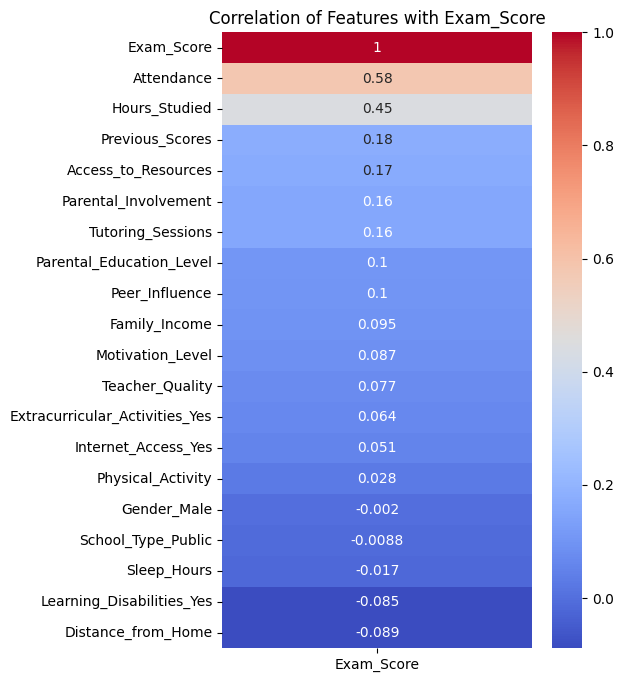

In [104]:
# correlation between the features and the target variable 'Exam_Score'
plt.figure(figsize=(5,8))
sns.heatmap(df.corr()['Exam_Score'].sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm')
plt.title('Correlation of Features with Exam_Score')
plt.show()

# **Check VIF score for Multicollinearity**

In [105]:
# change bool to int from X data
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# show the first 5 rows after encoding
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Gender_Male,Internet_Access_Yes,Extracurricular_Activities_Yes,Learning_Disabilities_Yes,School_Type_Public
0,23,84,0.0,2.0,7,73,0.0,0,0.0,1.0,2.0,3,0.0,0.0,67,1,1,0,0,1
1,19,64,0.0,1.0,8,59,0.0,2,1.0,1.0,0.0,4,1.0,1.0,61,0,1,0,0,1
2,24,98,1.0,1.0,7,91,1.0,2,1.0,1.0,1.0,4,2.0,0.0,74,1,1,1,0,1
3,29,89,0.0,1.0,8,98,1.0,1,1.0,1.0,0.0,4,0.0,1.0,71,1,1,1,0,1
4,19,92,1.0,1.0,6,65,1.0,3,1.0,2.0,1.0,4,1.0,0.0,70,0,1,1,0,1


In [106]:
# import libraries
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm

In [107]:
# copy the dataframe
df_vif = df.copy()

# Add constant
import statsmodels.api as sm
df_vif = sm.add_constant(df_vif)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = df_vif.columns
vif_data["VIF"] = [vif(df_vif.values, i)
                   for i in range(df_vif.shape[1])]

# dont show the constant column
print(vif_data[vif_data['Feature'] != 'const'])

                           Feature       VIF
1                    Hours_Studied  1.757783
2                       Attendance  2.281414
3             Parental_Involvement  1.120408
4              Access_to_Resources  1.126998
5                      Sleep_Hours  1.002531
6                  Previous_Scores  1.123861
7                 Motivation_Level  1.034914
8                Tutoring_Sessions  1.092520
9                    Family_Income  1.040317
10                 Teacher_Quality  1.025814
11                  Peer_Influence  1.038778
12               Physical_Activity  1.012473
13        Parental_Education_Level  1.037586
14              Distance_from_Home  1.025853
15                      Exam_Score  3.664992
16                     Gender_Male  1.001427
17             Internet_Access_Yes  1.016746
18  Extracurricular_Activities_Yes  1.019675
19       Learning_Disabilities_Yes  1.018870
20              School_Type_Public  1.002608
